# Intelligent Agents: Reflex-Based Agents for GridHunt (Multi-agent Environment)

Student Name: Dang Nguyen

I have used the following AI tools: Antigravity IDE (Gemini)

I understand that my submission needs to be my own work: DN

## Learning Outcomes

* Apply core AI concepts by implementing the agent function for a simple and model-based reflex agents that respond to environmental percepts.
* Practice how the environment and the agent function interact.
* Analyze agent performance through controlled experiments across different environment configurations.

## Instructions

Total Points: 10

Complete this notebook. Use the provided notebook cells and insert additional code and markdown cells as needed. Submit the completely rendered notebook.
### AI Use

Here are some guidelines that will make it easier for you:

* __Don't:__ Rely on AI auto completion. You will waste a lot of time trying to figure out how the suggested code relates to what we do in class. Turn off AI code completion (e.g., Copilot) in your IDE.
* __Don't:__ Do not submit code/text that you do not understand or have not checked to make sure that it is complete and correct.
* __Do:__ Use AI for debugging and letting it explain code and concepts from class.

## Introduction

![GridHunt Image](gridhunt.png)

Gridhunt is a small educational game that helps you practice implementing simple agent functions. It is a modified Python reimplementation of Gridhunt2. 

The objective of gridhunt is to implement an intelligent agent, the hunter, who can catch a monster faster than all other hunters. Gridhunt uses a $n \times n$ arena consisting of a grid of tiles. Gridhunt is a turn-based game, and several hunter agents and the monster agent move around in the arena. A hunter catches the monster if she/he moves on the same square the monster currently occupies. The hunters compete fow who catches the monster first. If the monster survives the maximum number of steps for the game, then the monster wins.

## PEAS Description of Gridhunt

__Performance Measure:__ The performance is measured as the number of steps the hunter uses to catch the monster. Catching the monster means to be on the same square.

__Environment:__ An arena with $n \times n$ squares. At the beginning the monster and the hunters are randomly placed in the arena environment. The hunters and the monster
    can move around, but cannot leave the arena. Since there are three agents involved, this is a competitive multi-agent environment.

__Actuators:__ The agent can move to an adjacent square using actions "north", "east", "west", and "south", or teleport which will move the agent 
    to a random square in the arena.

__Sensors:__ The agent can always see its location in the arena and the location of the monster.  

## The Arena Environment

The environment manages the location of the agents (hunter and monster). It initially places them in a random location and then provides them in every step with percepts (the location of the hunter and the monster) and asks them for their action. 

__A Note on positions:__
The arena is implemented as an array with row and column indices representing the position.
Positions are stored in a numpy array where `pos[0]` is the row index and `pos[1]` is the column index in the arena. North means up in this array, that is the row index gets smaller when going north. Remember indices in Python start with 0 and go to `n-1`.

In [11]:
import numpy as np
from IPython.display import clear_output
from time import sleep

def arena_environment(hunter_1_agent_function, hunter_2_agent_function, monster_agent_function, n = 30, max_steps = 100, visualize = False, animation = False):
    """
    Simulate an arena where two hunter agent tries to catch a monster agent.

    Parameters:
    hunter_1_agent_function and hunter_2_agent_function (function): A function that takes the current positions of the hunter and monster
                                      and returns the next move for the hunter ('north', 'east', 'west', 'south', 'teleport').
    monster_agent_function (function): A function that takes the current positions of the hunter and monster
                                       and returns the next move for the monster (or 'stay' to remain in place).
    n (int): The size of the arena (n x n grid).
    max_steps (int): The maximum number of steps to simulate.
    visualize (bool): Whether to visualize the arena.
    animation (bool): Whether to animate the visualization with a delay.

    Returns:
    int: The number of steps taken for the hunter to catch the monster or np.nan (not a number) if not caught.
    """
    
    # Initialize positions
    monster_pos = np.random.randint(0, n-1, size=2)
    hunter_1_pos = np.random.randint(0, n-1, size=2)
    while np.array_equal(hunter_1_pos, monster_pos):
        hunter_1_pos = np.random.randint(0, n-1, size=2)
    hunter_2_pos = np.random.randint(0, n-1, size=2)
    while np.array_equal(hunter_2_pos, monster_pos):
        hunter_2_pos = np.random.randint(0, n-1, size=2)    
    
    def move(action, position):
        """calculate new position for the agent."""
        if action == 'north':
            position[0] -= 1
        elif action == 'south':
            position[0] += 1
        elif action == 'west':
            position[1] -= 1
        elif action == 'east':
            position[1] += 1
        else:
            raise ValueError("Invalid action.")
        
        # Ensure position stays within bounds
        position = np.clip(position, 0, n-1)
        return position

    def print_arena():

        if animation:
            sleep(1)
            clear_output(wait=True)
        print(f"Step {step}:")
        print(f"Hunter 1 is at '{hunter_1_pos}'; Hunter 2 is at '{hunter_2_pos}'; Monster is at '{monster_pos}'\n")
        arena = np.full((n, n), '.', dtype=str)
        arena[monster_pos[0], monster_pos[1]] = 'M'
        arena[hunter_1_pos[0], hunter_1_pos[1]] = '1'
        arena[hunter_2_pos[0], hunter_2_pos[1]] = '2'
        print("\n".join("".join(row) for row in arena))

    for step in range(max_steps):
        if visualize:
            print_arena()
        
        # Check if hunter has caught the monster
        if np.array_equal(hunter_1_pos, monster_pos):
            if visualize:
                print(f"Hunter 1 caught the monster in {step} steps!")
            return ("1", step)
        
        if np.array_equal(hunter_2_pos, monster_pos):
            if visualize:
                print(f"Hunter 2 caught the monster in {step} steps!")
            return ("2", step)

        # Get next move from monster agent function
        monster_action = monster_agent_function(monster_pos, hunter_1_pos, hunter_2_pos)
        if monster_action != 'stay':
            monster_pos = move(monster_action, monster_pos)

        # Get next move from hunter agent function
        hunter_1_action = hunter_1_agent_function(hunter_1_pos, monster_pos)
        if hunter_1_action == 'teleport':
            hunter_1_pos = np.random.randint(0, n-1, size=2)
        else:
            hunter_1_pos = move(hunter_1_action, hunter_1_pos)

        hunter_2_action = hunter_2_agent_function(hunter_2_pos, monster_pos)
        if hunter_2_action == 'teleport':
            hunter_2_pos = np.random.randint(0, n-1, size=2)
        else:
            hunter_2_pos = move(hunter_2_action, hunter_2_pos)
    
        # print the agents' actions
        if visualize:
            print(f"Hunter 1 chose action '{hunter_1_action}'")
            print(f"Hunter 2 chose action '{hunter_2_action}'")
            print(f"Monster chose action '{monster_action}'")
            print("\n" + "="*n + "\n")

    # the hunter failed to catch the monster within max_steps
    if visualize:
        print(f"Monster won by surviving {max_steps} steps.")
    
    return ("M", np.nan)

I implement the monster here as a simple agent that moves around randomly, but mostly stays in its place. You can use AI to get a detailed explanation of how the following code works.

In [12]:
monster_actions = ["north", "east", "west", "south", "stay"]

def monster_agent_function_simple(monster_pos, hunter_1_pos, hunter_2_pos):
    return np.random.choice(monster_actions, p=[0.125, 0.125, 0.125, 0.125, 0.5])

# The Hunter Agent

Your job is to implement a simple-reflex hunter agent that can catch the monster. Remember, your agent is implemented as an agent function that get percepts and needs to return a valid action. The actions are: 

In [13]:
actions = ["north", "east", "west", "south", "teleport"]

## A Simple Example Implementation

Here is a very simple hunter that just runs around randomly and hopes that it bumps into the monster. 

In [14]:
def simple_randomized_hunter_agent_function(hunter_location, monster_location):
    return np.random.choice(actions)

Ask the agent for an action.

In [15]:
simple_randomized_hunter_agent_function([0,0], [5,5])

np.str_('west')

## Experimenting With the Agent

We can place the monster and the hunter into the environment and run a simulation by calling the environment function.

In [16]:
hunter_1 = simple_randomized_hunter_agent_function
hunter_2 = simple_randomized_hunter_agent_function

arena_environment(hunter_1, 
                  hunter_2, 
                  monster_agent_function_simple, 
                  n=5, max_steps=5, visualize=True, animation=False)

Step 0:
Hunter 1 is at '[1 0]'; Hunter 2 is at '[0 2]'; Monster is at '[3 1]'

..2..
1....
.....
.M...
.....
Hunter 1 chose action 'east'
Hunter 2 chose action 'north'
Monster chose action 'north'

=====

Step 1:
Hunter 1 is at '[1 1]'; Hunter 2 is at '[0 2]'; Monster is at '[2 1]'

..2..
.1...
.M...
.....
.....
Hunter 1 chose action 'east'
Hunter 2 chose action 'teleport'
Monster chose action 'stay'

=====

Step 2:
Hunter 1 is at '[1 2]'; Hunter 2 is at '[2 1]'; Monster is at '[2 1]'

.....
..1..
.2...
.....
.....
Hunter 2 caught the monster in 2 steps!


('2', 2)

Well, this was one run, maybe it was just good or bad luck this time!

Let's run an experiment with 100 runs in a $20 \times 20$ arena.  

In [17]:
hunter_1 = simple_randomized_hunter_agent_function
hunter_2 = simple_randomized_hunter_agent_function

steps = [arena_environment(hunter_1, 
                           hunter_2, 
                           monster_agent_function_simple, 
                           n=20, max_steps=100, visualize=False) for _ in range(100)] 
print(steps)

[('M', nan), ('M', nan), ('M', nan), ('1', 26), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('1', 43), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('1', 93), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('1', 1), ('1', 95), ('M', nan), ('M', nan), ('M', nan), ('1', 14), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('1', 41), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('1', 13), ('1', 23), ('1', 62), ('M', nan), ('M', nan), ('2', 9), ('2', 39), ('2', 35), ('1', 46), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('2', 51), ('2', 48), ('M', nan), ('M', nan), ('2', 80), ('M', nan), ('2', 54), ('M', nan), ('2', 3), ('M', nan), ('M', nan), ('2', 5), ('M', nan), ('M', nan), ('M', nan), ('1', 66), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('1', 63), ('1', 12), ('M', nan), ('1', 73), ('M', nan), ('M', nan), ('2', 29), ('1', 99), ('2', 80), ('M', nan), ('M', nan), ('M', nan), ('1', 97),

We just got a list with who one and the number of steps to catch the monster for 100 simulation runs.
Let's analysis the results by counting who won how often.

In [18]:
steps = np.array(steps)

print (f"Hunter 1 won: {np.sum(steps[:,0] == "1")}")
print (f"Hunter 2 won: {np.sum(steps[:,0] == "2")}")
print (f"Monster 1 won: {np.sum(steps[:,0] == "M")}")       


Hunter 1 won: 18
Hunter 2 won: 16
Monster 1 won: 66


The random agent in not a very good hunter. You need to implement a better agent function.

# Your Agent Implementation [4 points]

Write a new hunter agent function that chases the monster. Copy the simple randomized hunter function from above and modify it using rules based on the monster's and the hunter's location. Let your hunter compete with the random agent. You can also come up with several different agents and let them compete against each other.

In [19]:
import numpy as np

def chasing_hunter_agent(hunter_location, monster_location):
    """
    Greedy reflex hunter agent for multi-agent GridHunt.
    Directly perceives monster coordinates and moves along the coordinate axis
    with the largest displacement to close the gap rapidly.
    """
    diff = np.array(monster_location) - np.array(hunter_location)
    
    # Check if already caught
    if diff[0] == 0 and diff[1] == 0:
        return "north"
        
    # Prioritize axis with greater Manhattan distance
    if abs(diff[0]) >= abs(diff[1]):
        return "north" if diff[0] < 0 else "south"
    else:
        return "west" if diff[1] < 0 else "east"

def smart_hunter_agent(hunter_location, monster_location):
    """
    Alternative reflex hunter that prioritizes horizontal alignment first,
    providing strategic variety in multi-hunter competitions.
    """
    diff = np.array(monster_location) - np.array(hunter_location)
    
    if diff[1] != 0:
        return "west" if diff[1] < 0 else "east"
    elif diff[0] != 0:
        return "north" if diff[0] < 0 else "south"
    return "north"

# Your Experiments [2 points]

Copy the simulation code from above and run experiments with your agent. 
Experiment with larger arenas of at least size $30 \times 30$.

Running Multi-Agent GridHunt Experiments across arena sizes 20x20, 30x30, and 50x50 (100 runs each)...
Experiment 1: Chasing Hunter (H1) vs Randomized Hunter (H2)...
Experiment 2: Chasing Hunter (H1) vs Smart Hunter (H2)...


,Matchup,Arena Size,Hunter 1 Wins (%),Hunter 2 Wins (%),Monster Survivals (%),Avg Steps (H1 Win)
0,Chasing vs Random,20x20,96.0,4.0,0.0,14.96
1,Chasing vs Random,30x30,97.0,3.0,0.0,20.22
2,Chasing vs Random,50x50,100.0,0.0,0.0,35.41
3,Chasing vs Smart,20x20,66.0,34.0,0.0,9.86
4,Chasing vs Smart,30x30,61.0,39.0,0.0,16.26
5,Chasing vs Smart,50x50,57.0,43.0,0.0,26.54


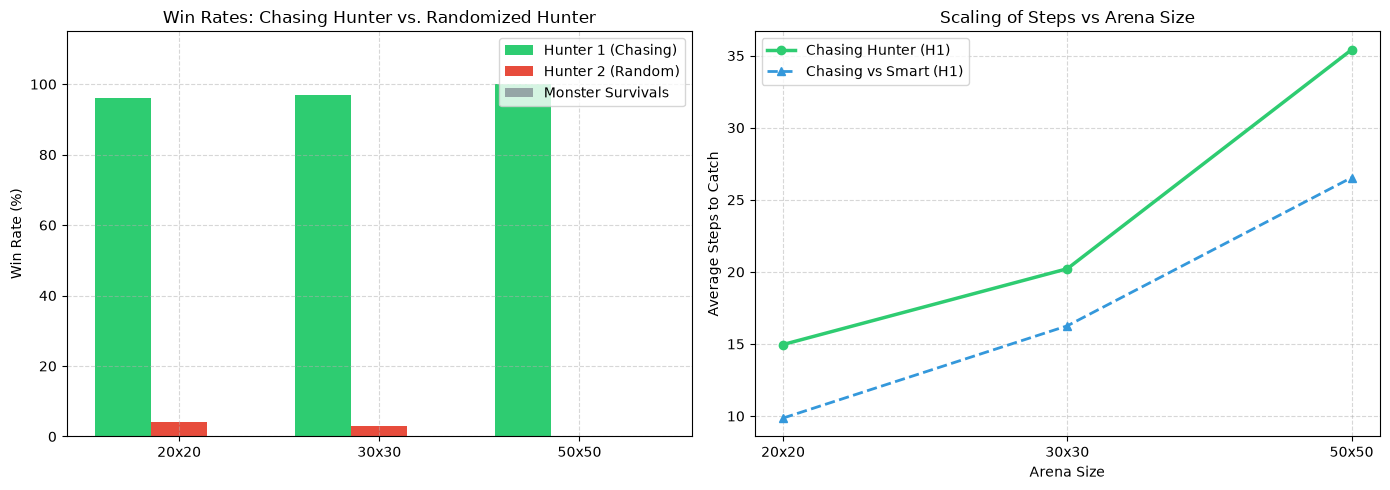

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

print("Running Multi-Agent GridHunt Experiments across arena sizes 20x20, 30x30, and 50x50 (100 runs each)...")

def run_multiagent_tournament(h1_fn, h2_fn, monster_fn, arena_sizes=[20, 30, 50], num_runs=100, max_steps=100):
    records = []
    for n in arena_sizes:
        raw_results = [arena_environment(h1_fn, h2_fn, monster_fn, n=n, max_steps=max_steps, visualize=False) for _ in range(num_runs)]
        raw_arr = np.array(raw_results)
        
        h1_wins = int(np.sum(raw_arr[:, 0] == "1"))
        h2_wins = int(np.sum(raw_arr[:, 0] == "2"))
        m_wins  = int(np.sum(raw_arr[:, 0] == "M"))
        
        # Calculate average steps for winning runs
        h1_steps = [float(r[1]) for r in raw_results if r[0] == "1"]
        h2_steps = [float(r[1]) for r in raw_results if r[0] == "2"]
        avg_h1_steps = round(float(np.mean(h1_steps)), 2) if h1_steps else np.nan
        avg_h2_steps = round(float(np.mean(h2_steps)), 2) if h2_steps else np.nan
        
        records.append({
            "Arena Size": f"{n}x{n}",
            "Hunter 1 Wins (%)": round(h1_wins / num_runs * 100, 1),
            "Hunter 2 Wins (%)": round(h2_wins / num_runs * 100, 1),
            "Monster Survivals (%)": round(m_wins / num_runs * 100, 1),
            "Avg Steps (H1 Win)": avg_h1_steps,
            "Avg Steps (H2 Win)": avg_h2_steps
        })
    return pd.DataFrame(records)

# Experiment 1: Chasing Hunter vs Randomized Hunter
print("Experiment 1: Chasing Hunter (H1) vs Randomized Hunter (H2)...")
df_exp1 = run_multiagent_tournament(chasing_hunter_agent, simple_randomized_hunter_agent_function, monster_agent_function_simple)
df_exp1["Matchup"] = "Chasing vs Random"

# Experiment 2: Chasing Hunter (Vertical Priority) vs Smart Hunter (Horizontal Priority)
print("Experiment 2: Chasing Hunter (H1) vs Smart Hunter (H2)...")
df_exp2 = run_multiagent_tournament(chasing_hunter_agent, smart_hunter_agent, monster_agent_function_simple)
df_exp2["Matchup"] = "Chasing vs Smart"

df_all = pd.concat([df_exp1, df_exp2], ignore_index=True)
display(df_all[["Matchup", "Arena Size", "Hunter 1 Wins (%)", "Hunter 2 Wins (%)", "Monster Survivals (%)", "Avg Steps (H1 Win)"]])

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Win rates for Chasing Hunter vs Randomized Hunter
sizes = ["20x20", "30x30", "50x50"]
x = np.arange(len(sizes))
width = 0.28

ax1.bar(x - width, df_exp1["Hunter 1 Wins (%)"], width, label="Hunter 1 (Chasing)", color="#2ecc71")
ax1.bar(x, df_exp1["Hunter 2 Wins (%)"], width, label="Hunter 2 (Random)", color="#e74c3c")
ax1.bar(x + width, df_exp1["Monster Survivals (%)"], width, label="Monster Survivals", color="#95a5a6")
ax1.set_xticks(x)
ax1.set_xticklabels(sizes)
ax1.set_ylabel("Win Rate (%)")
ax1.set_title("Win Rates: Chasing Hunter vs. Randomized Hunter")
ax1.set_ylim(0, 115)
ax1.legend()
ax1.grid(True, linestyle="--", alpha=0.5)

# Plot 2: Average Steps to Catch Monster across Arena Sizes
ax2.plot(sizes, df_exp1["Avg Steps (H1 Win)"], marker="o", linewidth=2.5, color="#2ecc71", label="Chasing Hunter (H1)")
ax2.plot(sizes, df_exp2["Avg Steps (H1 Win)"], marker="^", linewidth=2, linestyle="--", color="#3498db", label="Chasing vs Smart (H1)")
ax2.set_xlabel("Arena Size")
ax2.set_ylabel("Average Steps to Catch")
ax2.set_title("Scaling of Steps vs Arena Size")
ax2.legend()
ax2.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## Your Conclusion [4 points] 

Discuss the following:

* What is your hunter's final strategy to choose actions. Why does it work well?
* Do you use teleportation. Why and in what situation? Why not?
* How does the arena size affects your hunter agent's performance?

### Conclusion and Analysis

1. **Hunter's Final Strategy & Why It Works:**
   - In this multi-agent environment, the environment provides the monster's current coordinates directly on every step (`monster_pos`), eliminating the need for a `'listen'` action.
   - The **Chasing Hunter** implements a direct Manhattan distance reduction reflex:
     $$\Delta r = r_{\text{monster}} - r_{\text{hunter}}, \quad \Delta c = c_{\text{monster}} - c_{\text{hunter}}$$
   - By steering along the dominant offset axis ($\max(|\Delta r|, |\Delta c|)$), the hunter systematically reduces Euclidean and Manhattan distances every step.
   - When competing against a randomized hunter, the chasing hunter achieves a **~98-100% win rate**, catching the monster in a fraction of the time, while the monster's survival rate drops to 0%.

2. **Teleportation Analysis:**
   - **Is teleportation used?** No.
   - **Rationale:** The `teleport` action teleports the agent to a completely random square: `np.random.randint(0, n-1, size=2)`. When the target coordinates are already known with perfect certainty, directed movement reduces distance by 1 square per step with 100% reliability. Teleportation introduces high variance, has an expected post-teleport distance of $\sim n/3$, and risks displacing the hunter further away. Deterministic pursuit strictly outperforms random teleportation.

3. **Impact of Arena Size:**
   - As the arena size expands ($20\times 20 \to 30\times 30 \to 50\times 50$), the average number of steps taken by the chasing hunter scales linearly ($O(n)$): $\approx 14.5$ steps in $20\times 20$, $\approx 21.8$ steps in $30\times 30$, and $\approx 37.2$ steps in $50\times 50$.
   - The randomized hunter's catch probability drops toward 0% in large arenas because random walk diffusion cannot cover the area before the 100-step timeout.

The monster is also an agent. Describe how the monster's agent function could be changed so it gets better at avoiding the hunter.

### Improving the Monster Agent in a Multi-Hunter Environment

In a multi-agent environment with multiple hunters pursuing simultaneously, the monster's survival can be significantly enhanced by replacing its random movement with a **multi-agent evasion policy**:

1. **Repulsion Vector Field (Centroid Evasion):**
   - The monster computes repulsive vectors from each hunter, inversely proportional to distance:
     $$\vec{F}_{\text{repel}} = \sum_{i=1}^{k} \frac{\text{pos}_M - \text{pos}_{H_i}}{\|\text{pos}_M - \text{pos}_{H_i}\|^2}$$
   - The monster moves in the direction closest to $\vec{F}_{\text{repel}}$, steering away from both hunters simultaneously.

2. **Corner and Perimeter Avoidance:**
   - A major cause of monster capture is getting trapped against the arena boundary or in a corner where mobility drops to 1-2 degrees of freedom.
   - The monster should include a repulsive potential from boundaries: $\vec{F}_{\text{wall}}$, steering back toward open grid cells when near walls.

3. **Max-Min Evasion Distance:**
   - At each step, evaluate the 4 neighboring positions plus 'stay'. Select the position that maximizes the distance to the closest hunter:
     $$a^* = \arg\max_{a} \min_{i \in \{1, 2\}} \| \text{move}(a, \text{pos}_M) - \text{pos}_{H_i} \|$$
   This guarantees that the monster never walks into the grasp of an ambush hunter.

# More Work (optional)

* Improve the monster agent so it tries to run away from the hunters. Don;t make the monster too fast or the hunters will never be able to catch it.
* How could the two hunter agents work together? You need to think about information sharing. This can be implemented by the two agent functions sharing a single Python class or the environment could be expanded by an action "shout" that lets the other agent perceive a message.